# Where does GPU spatial analytics cross over?

This output-complete notebook compares an eight-thread Shapely/STRtree CPU
baseline with cuSpatial 25.04 on one RTX PRO 4000 Blackwell SFF. It asks how
point count, feature count, polygon complexity, selectivity, index build, and
result placement move the boundary.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
RESULTS = Path("results/published_results.csv")
EXCLUDED = Path("results/excluded_cases.csv")
results = pd.read_csv(RESULTS)
excluded = pd.read_csv(EXCLUDED)
results.shape, excluded.shape


((33, 72), (3, 22))

## Evidence checks

Every performance row is a median of three fresh-process replications. CPU and
GPU match counts agree, point/polygon pair signatures agree, and nearest-line
rows are published only where every pointwise distance passed the recorded
planar tolerance. Failed correctness controls remain visible in the diagnostic
table but are not converted into speedups.


In [2]:
assert results["replications"].eq(3).all()
assert results["gpu_end_to_end_speedup"].gt(0).all()
assert results["case_id"].is_unique
assert excluded["publication_status"].eq("excluded_from_performance_claims").all()
results.groupby("operation").size(), excluded.groupby("operation").size()


(operation
 direct_pip       3
 indexed_join    15
 nearest         10
 window           5
 dtype: int64,
 operation
 indexed_join    2
 nearest         1
 dtype: int64)

## Point scale changes both fixed cost and useful parallel work


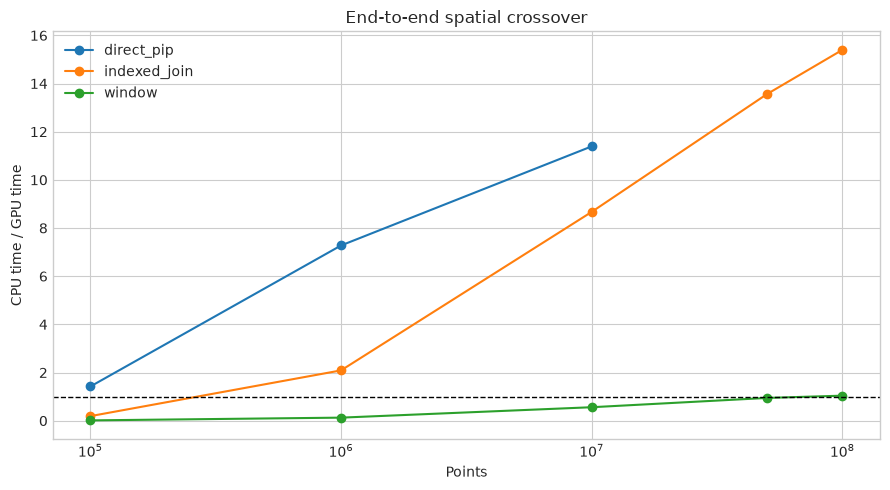

In [3]:
scale = results[results["sweep"].isin(["window_scale", "direct_scale", "join_scale"])].copy()
figure, axis = plt.subplots(figsize=(9, 5))
for operation, group in scale.groupby("operation"):
    ordered = group.sort_values("points")
    axis.plot(ordered["points"], ordered["gpu_end_to_end_speedup"], marker="o", label=operation)
axis.set_xscale("log")
axis.axhline(1.0, color="black", linewidth=1, linestyle="--")
axis.set(xlabel="Points", ylabel="CPU time / GPU time", title="End-to-end spatial crossover")
axis.legend()
figure.tight_layout()
plt.show()


## Polygon count, vertices, and selectivity move different stages


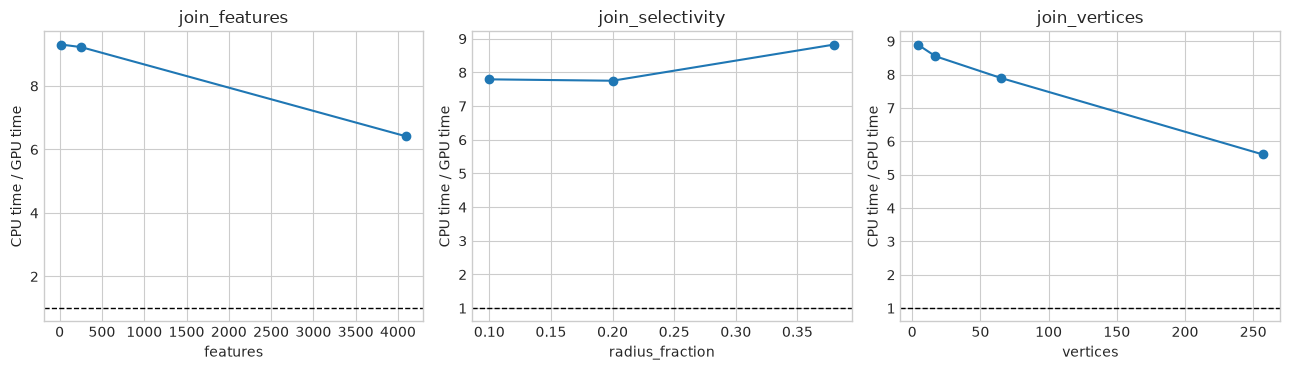

In [4]:
axes = results[results["sweep"].isin(["join_features", "join_vertices", "join_selectivity"])].copy()
figure, panels = plt.subplots(1, 3, figsize=(13, 3.8))
for panel, (sweep, group) in zip(panels, axes.groupby("sweep")):
    ordered = group.sort_values("axis_value")
    panel.plot(ordered["axis_value"], ordered["gpu_end_to_end_speedup"], marker="o")
    panel.axhline(1.0, color="black", linewidth=1, linestyle="--")
    panel.set(title=sweep, xlabel=ordered["axis"].iloc[0], ylabel="CPU time / GPU time")
figure.tight_layout()
plt.show()


## Index reuse is a lifecycle, not one universal number


In [5]:
reuse = results[results["operation"] == "indexed_join"].copy()
reuse[[
    "sweep", "axis_value", "reused_index_break_even_queries_median",
    "materialized_reuse_break_even_queries_median", "gpu_resident_query_speedup",
]].sort_values(["sweep", "axis_value"]).head(20)


,sweep,axis_value,reused_index_break_even_queries_median,materialized_reuse_break_even_queries_median,gpu_resident_query_speedup
3,join_features,1.600000e+01,0.0,0.0,19.126297
4,join_features,2.560000e+02,0.0,0.0,20.131340
5,join_features,4.096000e+03,0.0,0.0,23.144473
6,join_scale,1.000000e+05,68.0,NaN,1.230514
7,join_scale,1.000000e+06,0.0,0.0,6.513391
8,join_scale,1.000000e+07,0.0,0.0,22.912638
10,join_scale,5.000000e+07,0.0,0.0,28.655621
9,join_scale,1.000000e+08,0.0,0.0,33.919909
11,join_selectivity,1.000000e-01,0.0,0.0,9.894354
12,join_selectivity,2.000000e-01,0.0,0.0,15.993029


## Correctness boundaries are part of the result


In [6]:
excluded[[
    "sweep", "axis_value", "successful_replications", "failed_replications",
    "returncodes", "failure_summary", "publication_status",
]].sort_values(["sweep", "axis_value"])


,sweep,axis_value,successful_replications,failed_replications,returncodes,failure_summary,publication_status
0,join_features,16384.00,2,1,-11,process exited without stderr,excluded_from_performance_claims
1,join_selectivity,0.48,2,1,-11,process exited without stderr,excluded_from_performance_claims
2,nearest_scale,10000.00,0,3,1,AssertionError: nearest distances differ: sum_...,excluded_from_performance_claims


In [7]:
import json

quadtree = pd.DataFrame(json.loads(Path("results/quadtree_diagnostic.json").read_text()))
nearest_100k = pd.DataFrame(json.loads(Path("results/nearest_100k_diagnostic.json").read_text()))
nearest_1m = pd.DataFrame(json.loads(Path("results/nearest_1m_diagnostic.json").read_text()))
quadtree, nearest_100k[["multiplier", "maximum_absolute_error", "mismatches"]], nearest_1m[["multiplier", "maximum_absolute_error", "mismatches"]]


(   correct  cpu_matches  depth  features  gpu_matches  leaves  max_size  \
 0    False      4444679     15      1024          245  255448       128   
 1     True      4444679     15      1024      4444679   65544       256   
 
      points  points_in_leaves  quad_pairs  vertices  
 0  10000000           9905288          63        17  
 1  10000000          10000000       54971        17  ,
    multiplier  maximum_absolute_error  mismatches
 0        0.75            3.460655e-11           0
 1        1.00            3.460655e-11           0
 2        2.00            3.460655e-11           0
 3        4.00            3.460655e-11           0,
    multiplier  maximum_absolute_error  mismatches
 0        0.75                0.000925          11
 1        1.00                0.000925          11
 2        2.00                0.000925          11
 3        4.00                0.000925          11)

## Scope

The data is deterministic synthetic planar geometry in `[0, 1)^2`. The study
does not cover geographic CRS transforms, invalid real-world polygons, file
parsing, spherical distance, dynamic index updates, or multi-GPU execution.
The notebook analyzes derived confirmation evidence; rerunning it does not
rerun the GPU benchmark.
